<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Atividade_2_Pandas_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

## Desafio de Pandas com o Dataset Netflix para Pós-Graduação

Este desafio tem como objetivo aprimorar suas habilidades em manipulação e análise de dados usando a biblioteca Pandas do Python, com foco no dataset de títulos da Netflix. Vocês deverão responder a uma série de perguntas e realizar transformações nos dados. Mãos à obra!

### Recursos e Funções Sugeridas

Para completar este desafio, vocês podem usar diversas funções da biblioteca Pandas. Abaixo estão algumas que podem ser úteis para o dataset da Netflix:

**Carregamento e Inspeção de Dados:**
*   `pd.read_csv()`: Para carregar dados.
*   `df.head()`, `df.info()`: Para visão inicial.
*   `df['type'].value_counts()`: Útil para ver a distribuição entre Filmes e Séries.

**Manipulação de Strings e Datas:**
*   `df['date_added'].str.strip()`: Para limpar espaços em branco.
*   `pd.to_datetime()`: Para converter colunas de data.
*   `df['duration'].str.extract()`: Para extrair números de durações (minutos ou temporadas).

**Filtragem e Agregação:**
*   `df[df['release_year'] > 2020]`: Para filtrar lançamentos recentes.
*   `df.groupby('country').size()`: Para contar produções por país.

### Tarefa 1: Carregamento e Visão Geral da Netflix

1.  **Carregue** o dataset da Netflix.
    URL: `https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv`
2.  **Exiba** as primeiras 5 linhas.
3.  **Verifique** a quantidade de Filmes vs. Séries.
4.  **Identifique** colunas com valores nulos.

In [3]:
#1
data = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv')
data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [4]:
#2 Exiba as primeiras 5 linhas.
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [6]:
#3 Verifique a quantidade de Filmes vs. Séries.
data['type'].value_counts()

,count
type,
Movie,5377
TV Show,2410


In [7]:
#4 Identifique colunas com valores nulos.
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


### Tarefa 2: Limpeza e Pré-processamento de Dados (Netflix)

1.  **Limpeza de Datas**: Converta a coluna `date_added` para o formato datetime do Pandas. (Dica: use `str.strip()` antes de converter).
2.  **Tratamento de Nulos**: Preencha os valores ausentes na coluna `country` com 'Unknown' e na coluna `director` com 'Not Available'.
3.  **Extração Numérica**: Crie uma nova coluna `duration_num` que contenha apenas o valor numérico da coluna `duration` (ex: '90 min' vira 90, '2 Seasons' vira 2).
4.  **Categorização**: Crie uma coluna `is_movie` que seja 1 se o tipo for 'Movie' e 0 caso contrário.

In [8]:
#criar uma copia do data original para iniciar a limpeza.
df = data.copy()

In [9]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [10]:
#1 Limpeza de Datas: Converta a coluna date_added para o formato datetime do Pandas. (Dica: use str.strip() antes de converter).
print(df['date_added'])
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
print(df['date_added'])

0          August 14, 2020
1        December 23, 2016
2        December 20, 2018
3        November 16, 2017
4          January 1, 2020
               ...        
7782      October 19, 2020
7783         March 2, 2019
7784    September 25, 2020
7785      October 31, 2020
7786         March 1, 2020
Name: date_added, Length: 7787, dtype: object
0      2020-08-14
1      2016-12-23
2      2018-12-20
3      2017-11-16
4      2020-01-01
          ...    
7782   2020-10-19
7783   2019-03-02
7784   2020-09-25
7785   2020-10-31
7786   2020-03-01
Name: date_added, Length: 7787, dtype: datetime64[ns]


In [11]:
#2 Tratamento de Nulos: Preencha os valores ausentes na coluna country com 'Unknown' e na coluna director com 'Not Available'.
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Not Available')

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,718
country,0
date_added,10
release_year,0
rating,7
duration,0


In [12]:
#3 Extração Numérica: Crie uma nova coluna duration_num que contenha apenas o valor numérico da coluna duration (ex: '90 min' vira 90, '2 Seasons' vira 2).
print(df[['duration', 'type']].head())

df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df[['duration', 'type', 'duration_num']].head()

    duration     type
0  4 Seasons  TV Show
1     93 min    Movie
2     78 min    Movie
3     80 min    Movie
4    123 min    Movie


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1981/3389662451.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


,duration,type,duration_num
0,4 Seasons,TV Show,4.0
1,93 min,Movie,93.0
2,78 min,Movie,78.0
3,80 min,Movie,80.0
4,123 min,Movie,123.0


In [13]:
#4 Categorização: Crie uma coluna is_movie que seja 1 se o tipo for 'Movie' e 0 caso contrário.
df['is_movie'] = (df['type'] == 'Movie').astype(int)

display(df[['duration', 'type', 'is_movie']].head())

df['is_movie'].value_counts()

,duration,type,is_movie
0,4 Seasons,TV Show,0
1,93 min,Movie,1
2,78 min,Movie,1
3,80 min,Movie,1
4,123 min,Movie,1


,count
is_movie,
1,5377
0,2410


### Tarefa 3: Análise Exploratória de Dados (EDA) - Expandida

1.  **Top 10 Países**: Quais são os 10 países que mais produzem conteúdo?
2.  **Sazonalidade**: Qual o mês com maior volume de novos títulos adicionados ao catálogo?
3.  **Diretores**: Quem são os 5 diretores com mais títulos na plataforma?
4.  **Distribuição de Rating**: Qual a classificação indicativa predominante?

In [14]:
#3.1  Top 10 Países: Quais são os 10 países que mais produzem conteúdo?

df['country'].value_counts().head(10)

,count
country,
United States,2555
India,923
Unknown,507
United Kingdom,397
Japan,226
South Korea,183
Canada,177
Spain,134
France,115


In [15]:
#3.2 Sazonalidade: Qual o mês com maior volume de novos títulos adicionados ao catálogo?
df['Month'] = df['date_added'].dt.month.astype('Int64')

df['Month'].value_counts()

,count
Month,
12,833
10,785
1,757
11,738
3,669
9,619
8,618
4,601
7,600


In [16]:
#3.3 Diretores: Quem são os 5 diretores com mais títulos na plataforma?
df['director'].value_counts().head(6)

,count
director,
Not Available,2389
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12


In [17]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,is_movie,Month
0,s1,TV Show,3%,Not Available,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,4.0,0,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,93.0,1,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",78.0,1,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",80.0,1,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,123.0,1,1


In [18]:
#3.4 Distribuição de Rating: Qual a classificação indicativa predominante?

rating_counts = df['rating'].value_counts()

predominante = rating_counts.idxmax()

print(f"A classificação indicativa predominante é: {predominante}")

print("\nTop 5 classificações:")
print(rating_counts.head(5))

A classificação indicativa predominante é: TV-MA

Top 5 classificações:
rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
Name: count, dtype: int64


### Tarefa 4: Manipulações Avançadas e Insights

1.  **Análise de Séries**: Qual a média de temporadas das séries e qual o máximo encontrado?
2.  **Evolução da Duração**: Como a duração média dos filmes (`Movie`) variou nos últimos 10 anos?
3.  **Filtro por Gênero**: Identifique títulos que são simultaneamente 'Documentaries' e produzidos no 'United Kingdom'.
4.  **Segmentação por Era**: Comparação da proporção de Filmes vs Séries em títulos 'Classic' (pré-2010) e 'Modern' (2010+).

In [19]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,is_movie,Month
0,s1,TV Show,3%,Not Available,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,4.0,0,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,93.0,1,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",78.0,1,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",80.0,1,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,123.0,1,1


In [20]:
#4.1 Análise de Séries: Qual a média de temporadas das séries e qual o máximo encontrado?
series_df = df[df['type'] == 'TV Show']
medias_series = series_df['duration_num'].mean()
max_temporadas = series_df['duration_num'].max()

print(f'A média de temporadas: {medias_series}')
print(f'Máximo de tempordadas: {max_temporadas}')

A média de temporadas: 1.7759336099585061
Máximo de tempordadas: 16.0


In [21]:
# Curiosidade: Qual é a série com mais temporadas?
idx_max = series_df['duration_num'].idxmax()

# Acessa a linha completa usando esse índice
serie_info = series_df.loc[idx_max]

print(f"A série com mais temporadas é '{serie_info['title']}' com {serie_info['duration_num']} temporadas.")

A série com mais temporadas é 'Grey's Anatomy' com 16.0 temporadas.


In [22]:
#4.2 Evolução da Duração: Como a duração média dos filmes (Movie) variou nos últimos 10 anos?
movie_df = df[df['type'] == 'Movie']
anolimite = movie_df['release_year'].max() - 10

movie_10anos = movie_df[movie_df['release_year']> anolimite]

media_year = movie_10anos.groupby('release_year')['duration_num'].mean()

print("Média de duração por ano (últimos 10 anos):")
media_year

Média de duração por ano (últimos 10 anos):


,duration_num
release_year,
2012,100.620253
2013,98.752475
2014,100.266393
2015,99.827225
2016,95.112150
2017,94.836022
2018,96.170300
2019,93.457045
2020,89.795620


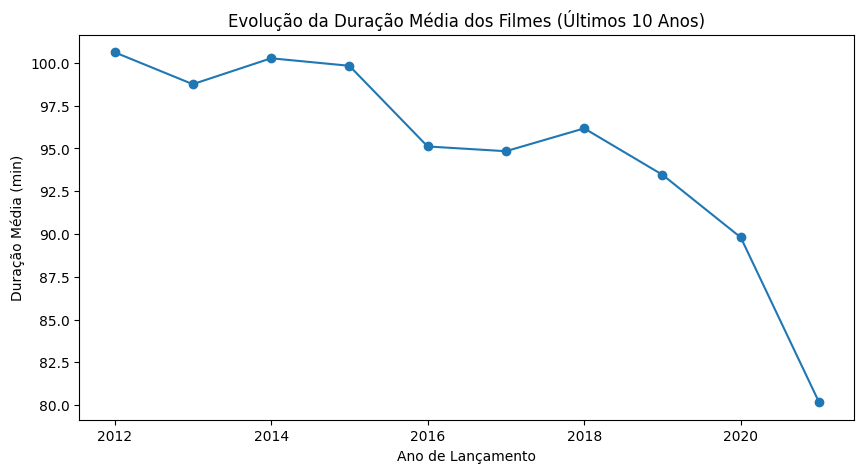

In [23]:
import matplotlib.pyplot as plt

media_year.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Evolução da Duração Média dos Filmes (Últimos 10 Anos)')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Duração Média (min)')
plt.show()

In [24]:
#4.3 Filtro por Gênero: Identifique títulos que são simultaneamente 'Documentaries' e produzidos no 'United Kingdom'.

filtro_docs_uk = (df['listed_in'].str.contains('Documentaries', na=False)) & \
                 (df['country'].str.contains('United Kingdom', na=False))

filtro_docs_uk.value_counts()

,count
False,7668
True,119


In [25]:
# 4.4 Segmentação por Era: Comparação da proporção de Filmes vs Séries em títulos 'Classic' (pré-2010) e 'Modern' (2010+).

df['era'] = df['release_year'].apply(lambda x: 'Classic' if x < 2010 else 'Modern')

proporcao_era = pd.crosstab(df['era'], df['type'], normalize='index') * 100

print("Proporção de Filmes vs Séries por Era (%):")
proporcao_era


Proporção de Filmes vs Séries por Era (%):


type,Movie,TV Show
era,,
Classic,85.216653,14.783347
Modern,66.172466,33.827534


### Tarefa 5: Conclusão

Escreva um resumo sobre o que você descobriu no catálogo da Netflix. Qual tipo de conteúdo predomina? Quais países são os maiores hubs de produção e como a biblioteca evoluiu nos últimos anos?

O catálogo evoluiu de filmes clássicos para séries originais. O conteúdo adulto (TV-MA) e os EUA predominam, seguidos por Índia e Reino Unido. A estratégia atual foca na retenção via séries e produções internacionais, lançamentos em períodos estratégicos como dezembro e janeiro(férias).